In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("biaiscience/dogs-vs-cats")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Jatin\.cache\kagglehub\datasets\biaiscience\dogs-vs-cats\versions\1


In [9]:
import os

data_dir = r"C:\Users\Jatin\.cache\kagglehub\datasets\biaiscience\dogs-vs-cats\versions\1"
print(os.listdir(data_dir))


['sorted_data', 'test', 'train']


In [11]:
# Point to the nested folders that hold the actual images
train_dir = os.path.join(data_dir, "train", "train") 
test_dir = os.path.join(data_dir, "test", "test")

# Now this will show you the 25,000 image files
print("Train samples:", len(os.listdir(train_dir))) 
# This will show the 12,500 test images
print("Test samples:", len(os.listdir(test_dir)))

Train samples: 25000
Test samples: 12500


In [13]:
import os
import shutil

# --- 1. Define your source and new base directories ---

# This is the path to your 25,000 mixed images
original_train_dir = r"C:\Users\Jatin\.cache\kagglehub\datasets\biaiscience\dogs-vs-cats\versions\1\train\train"

# This is where we will create our new, sorted folders
base_dir = r"C:\Users\Jatin\.cache\kagglehub\datasets\biaiscience\dogs-vs-cats\versions\1\sorted_data"

print(f"Reading images from: {original_train_dir}")
print(f"Creating new sorted folders in: {base_dir}")

# --- 2. Create the new directory structure ---
# We are creating:
# sorted_data/
# ├── train/
# │   ├── cats/
# │   └── dogs/
# └── validation/
#     ├── cats/
#     └── dogs/

# Define all the new paths
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')

validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

# Use os.makedirs() to create all directories
# exist_ok=True prevents an error if you run the script twice
os.makedirs(train_cats_dir, exist_ok=True)
os.makedirs(train_dogs_dir, exist_ok=True)
os.makedirs(validation_cats_dir, exist_ok=True)
os.makedirs(validation_dogs_dir, exist_ok=True)

# --- 3. Get all filenames from the original directory ---
all_filenames = os.listdir(original_train_dir)

# --- 4. Copy files into the new structure, splitting them apart ---
# We'll put 10,000 of each in 'train' and 2,500 of each in 'validation'.

print("Sorting and copying files... This may take a minute.")

copied_count = 0
for filename in all_filenames:
    src_path = os.path.join(original_train_dir, filename)
    
    try:
        # Check if the file is a 'cat' image
        if filename.startswith('cat'):
            file_num = int(filename.split('.')[1])
            if file_num < 10000:
                # Copy to train/cats
                shutil.copy(src_path, os.path.join(train_cats_dir, filename))
            elif file_num < 12500: # Use images 10000 to 12499 for validation
                # Copy to validation/cats
                shutil.copy(src_path, os.path.join(validation_cats_dir, filename))
            
        # Check if the file is a 'dog' image
        elif filename.startswith('dog'):
            file_num = int(filename.split('.')[1])
            if file_num < 10000:
                # Copy to train/dogs
                shutil.copy(src_path, os.path.join(train_dogs_dir, filename))
            elif file_num < 12500: # Use images 10000 to 12499 for validation
                # Copy to validation/dogs
                shutil.copy(src_path, os.path.join(validation_dogs_dir, filename))
        
        copied_count += 1
        if copied_count % 5000 == 0:
            print(f"Copied {copied_count} / 25000 files...")

    except Exception as e:
        print(f"Could not process {filename}: {e}")


print("\n--- File Sorting Complete! ---")
print(f"Total training cat images: {len(os.listdir(train_cats_dir))}")
print(f"Total training dog images: {len(os.listdir(train_dogs_dir))}")
print(f"Total validation cat images: {len(os.listdir(validation_cats_dir))}")
print(f"Total validation dog images: {len(os.listdir(validation_dogs_dir))}")

Reading images from: C:\Users\Jatin\.cache\kagglehub\datasets\biaiscience\dogs-vs-cats\versions\1\train\train
Creating new sorted folders in: C:\Users\Jatin\.cache\kagglehub\datasets\biaiscience\dogs-vs-cats\versions\1\sorted_data
Sorting and copying files... This may take a minute.
Copied 5000 / 25000 files...
Copied 10000 / 25000 files...
Copied 15000 / 25000 files...
Copied 20000 / 25000 files...
Copied 25000 / 25000 files...

--- File Sorting Complete! ---
Total training cat images: 10000
Total training dog images: 10000
Total validation cat images: 2500
Total validation dog images: 2500


In [15]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [17]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 [==============================] - 14s 0us/step


In [19]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [21]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 256)               2097408   
                                                                 
 dense_1 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16,812,353
Trainable params: 16,812,353
Non-trainable params: 0
_________________________________________________________________


In [25]:
conv_base.trainable = False

In [39]:
import tensorflow as tf

# Path to the new folders you just created
new_train_dir = r"C:\Users\Jatin\.cache\kagglehub\datasets\biaiscience\dogs-vs-cats\versions\1\sorted_data\train"
new_val_dir = r"C:\Users\Jatin\.cache\kagglehub\datasets\biaiscience\dogs-vs-cats\versions\1\sorted_data\validation"

# This one command loads, shuffles, and batches your data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    new_train_dir,
    image_size=(150, 150), 
    batch_size=32,
    label_mode='binary' # 'binary' for 2 classes (cat/dog)
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    new_val_dir,
    image_size=(150, 150),
    batch_size=32,
    label_mode='binary'
)

# Keras will automatically label 'cats' as 0 and 'dogs' as 1
print(f"Class names: {train_dataset.class_names}")

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Class names: ['cats', 'dogs']


In [40]:
def process(image,label):
    image=tf.cast(image/255. ,tf.float32)
    return image,label

train_dataset=train_dataset.map(process)
validation_dataset=validation_dataset.map(process)

In [41]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
# history = model.fit(train_dataset,epochs=10,validation_data=validation_dataset)

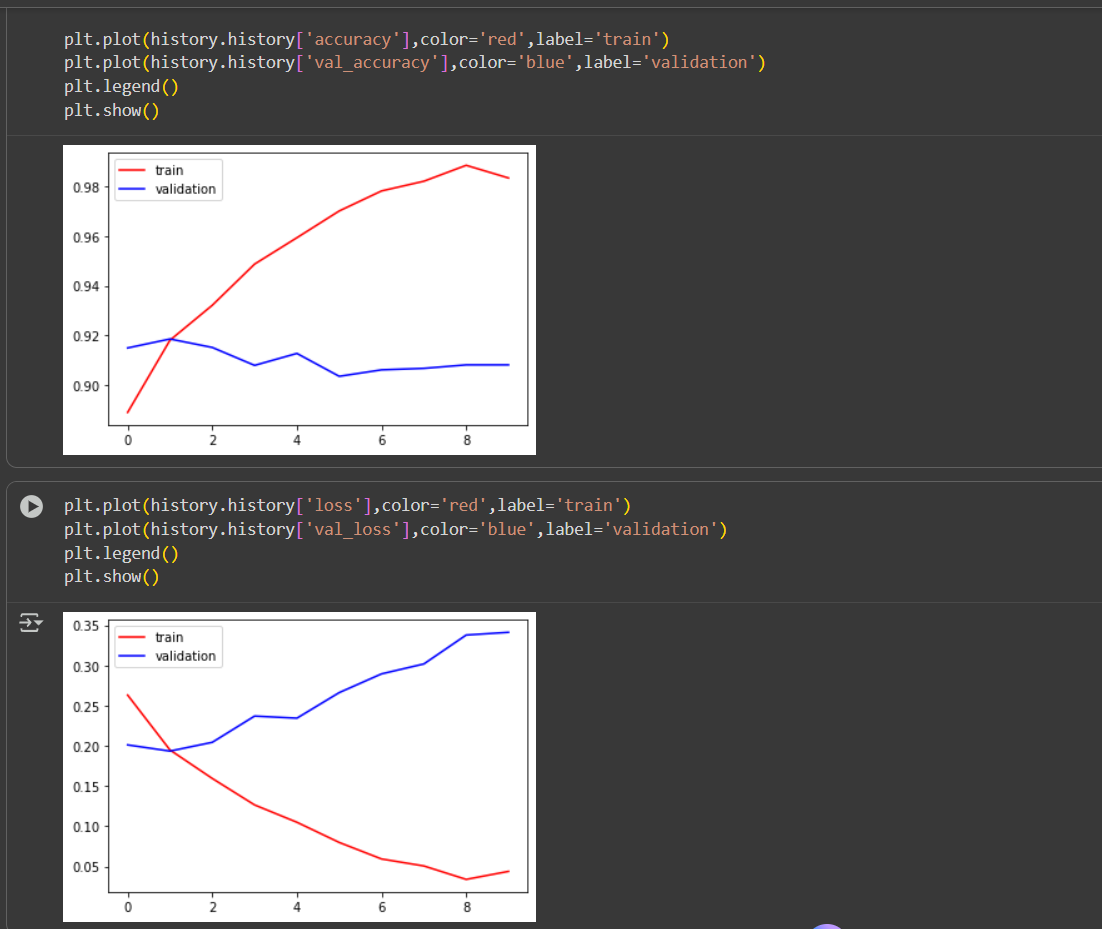

In [45]:
#overfitting ko shi krne ke liey data agumentation lgado 

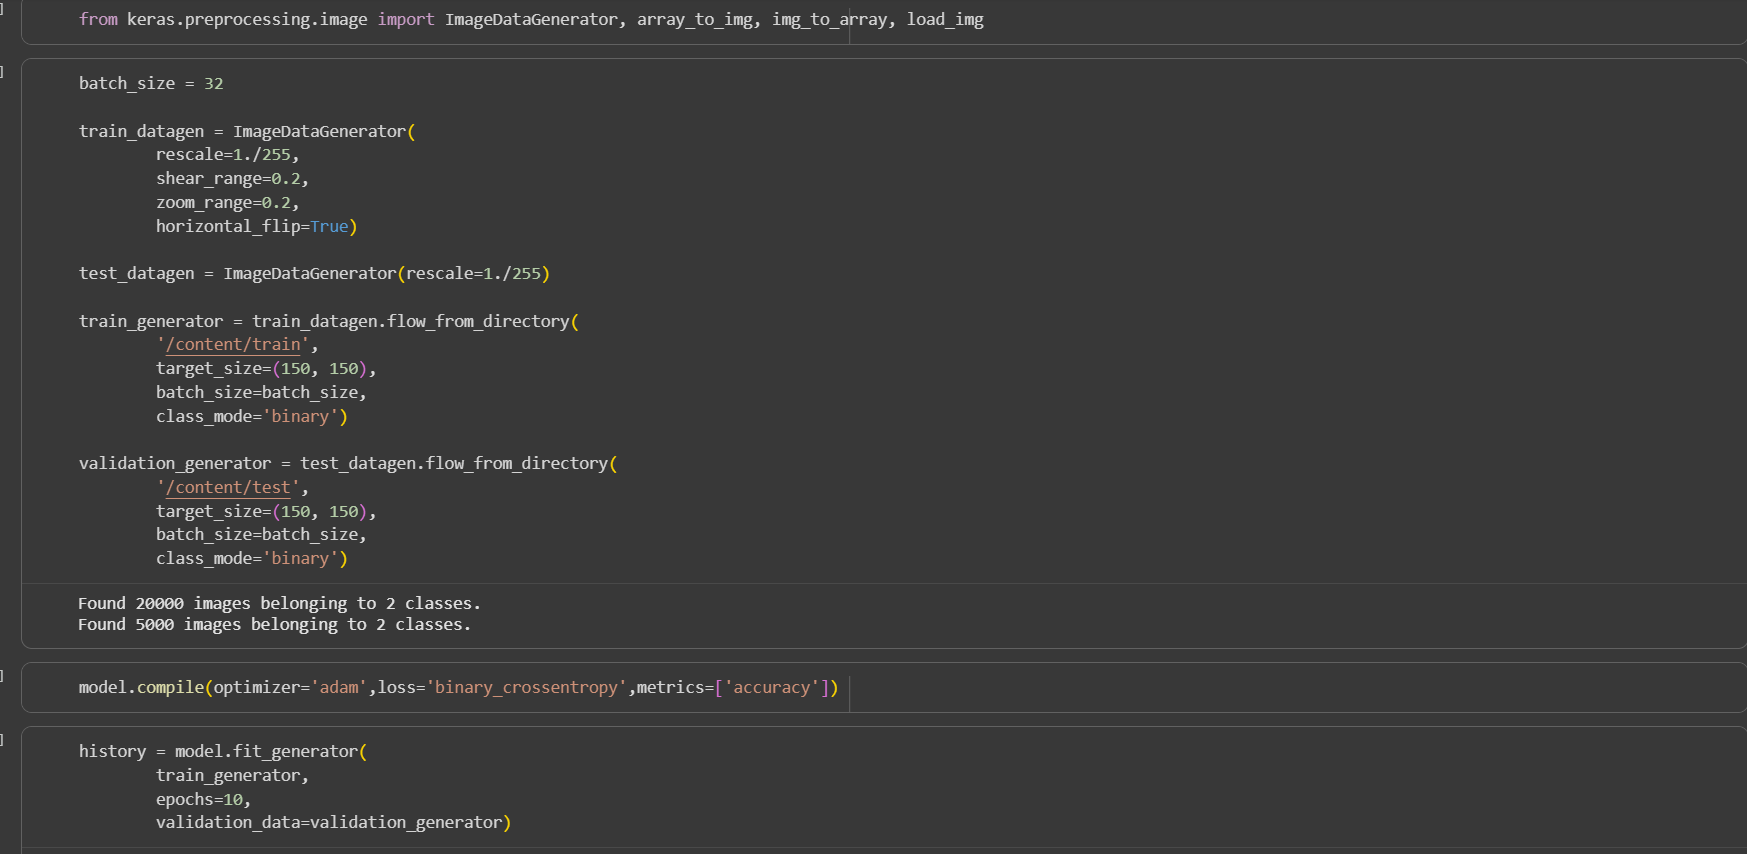

<h1>Results after</h1>

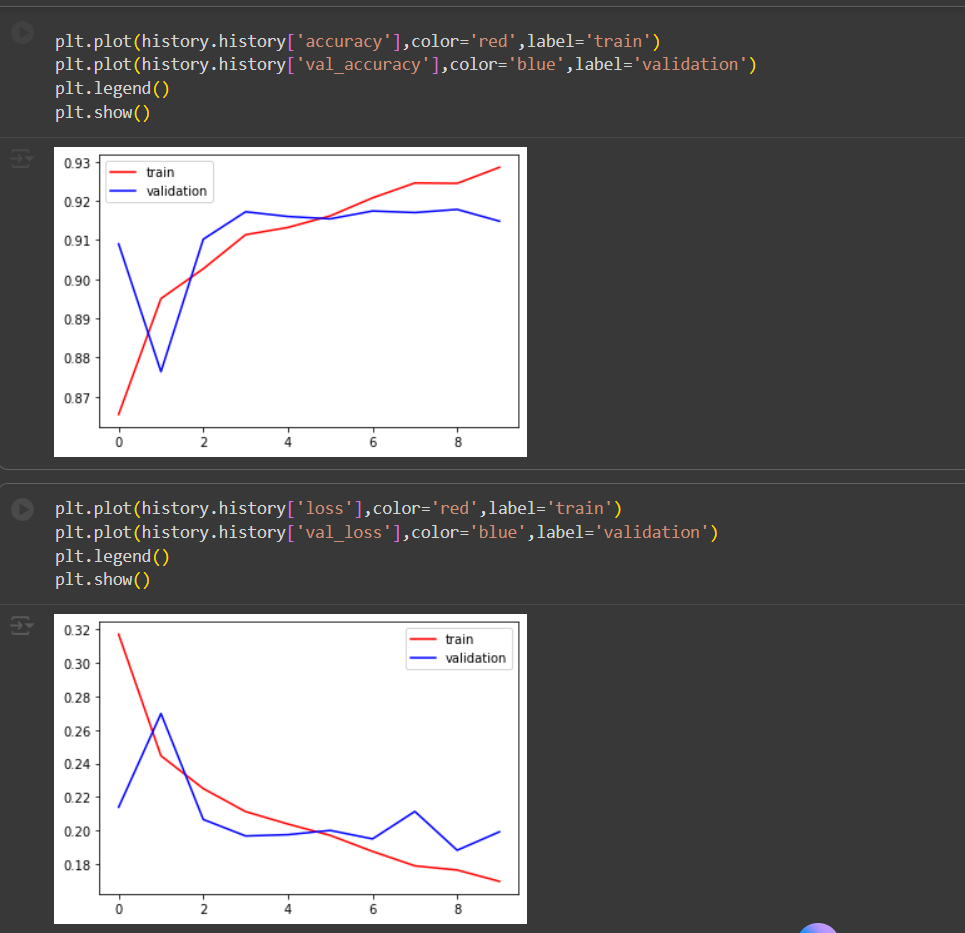

##Fine Tuning

In [51]:
# conv_base.trainable = True

# set_trainable = False

# for layer in conv_base.layers:
#   if layer.name == 'block5_conv1':
#     set_trainable = True
#   if set_trainable:
#     layer.trainable = True
#   else:
#     layer.trainable = False

# for layer in conv_base.layers:
#   print(layer.name,layer.trainable)

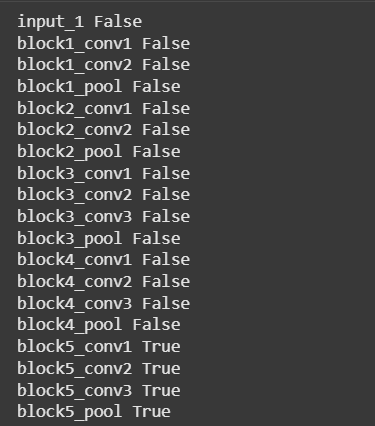

<h1>Result for Fine Tuning</h1>

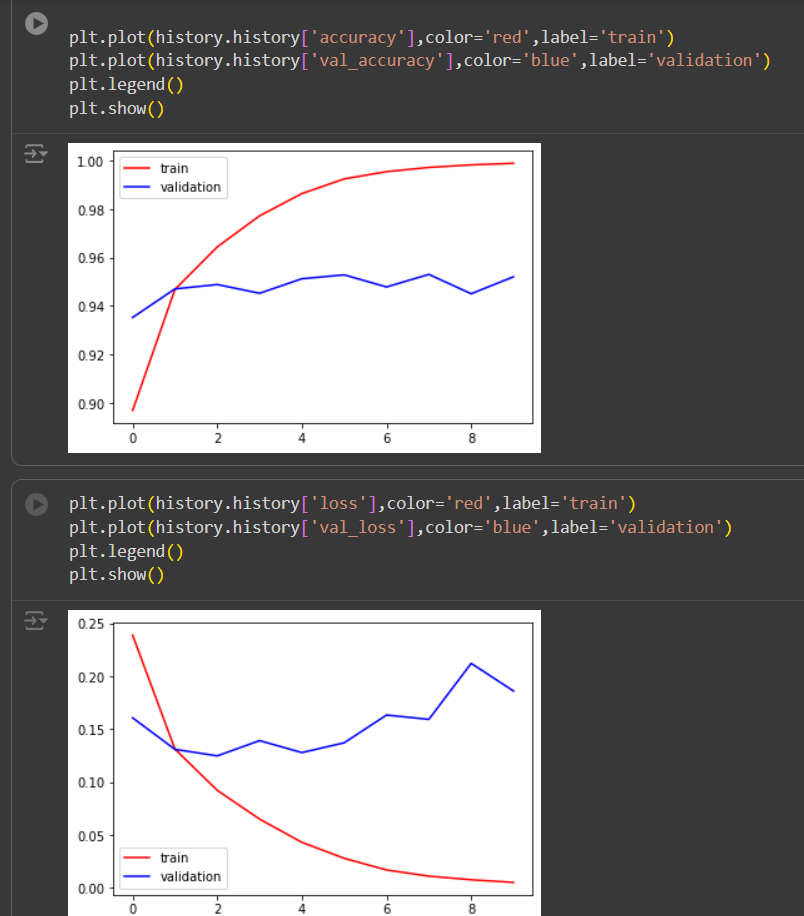